# NPPE3 Kaggle Training Notebook

This notebook uses the EDA result: this is a paired 4x low-light restoration task, so the baseline below jointly learns denoising, illumination correction, and super-resolution.

In [1]:
import os
import math
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
    torch.set_float32_matmul_precision('high')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)
if DEVICE == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))
    print('VRAM (GB):', round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2))

Device: cuda
GPU: Tesla T4
VRAM (GB): 14.56


In [2]:
DATASET_ROOT = Path('/kaggle/input/competitions/dlp-jan-2026-nppe-3')
TRAIN_INPUT = DATASET_ROOT / 'train' / 'train' / 'input'
TRAIN_GT = DATASET_ROOT / 'train' / 'train' / 'ground_truth'
TEST_INPUT = DATASET_ROOT / 'test' / 'test' / 'input'
SAMPLE_SUB = DATASET_ROOT / 'sample_submission.csv'

OUTPUT_DIR = Path('/kaggle/working/nppe3_outputs')
PRED_DIR = OUTPUT_DIR / 'predictions'
CKPT_PATH = OUTPUT_DIR / 'best_model.pt'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PRED_DIR.mkdir(parents=True, exist_ok=True)

CFG = {
    'scale': 4,
    'full_hr_ratio': 1250 / 312,
    'lr_patch': 64,
    'hr_patch': 256,
    'batch_size': 12,
    'epochs': 20,
    'lr': 1e-4,
    'weight_decay': 1e-6,
    'grad_clip': 1.0,
    'num_workers': 2,
    'val_ratio': 0.1,
    'amp': True,
    'max_val_images': 60,
}
CFG

{'scale': 4,
 'full_hr_ratio': 4.006410256410256,
 'lr_patch': 64,
 'hr_patch': 256,
 'batch_size': 12,
 'epochs': 20,
 'lr': 0.0001,
 'weight_decay': 1e-06,
 'grad_clip': 1.0,
 'num_workers': 2,
 'val_ratio': 0.1,
 'amp': True,
 'max_val_images': 60}

In [3]:
def list_images(folder):
    exts = {'.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'}
    return sorted([p for p in folder.iterdir() if p.suffix.lower() in exts])

train_input_files = list_images(TRAIN_INPUT)
train_gt_files = list_images(TRAIN_GT)
test_input_files = list_images(TEST_INPUT)

train_input_map = {p.stem: p for p in train_input_files}
train_gt_map = {p.stem: p for p in train_gt_files}
ids = sorted(set(train_input_map) & set(train_gt_map))

print('Train pairs:', len(ids))
print('Test images:', len(test_input_files))
assert len(ids) == 1200, 'Unexpected train pair count.'

rng = random.Random(SEED)
rng.shuffle(ids)
val_count = int(len(ids) * CFG['val_ratio'])
val_ids = ids[:val_count]
train_ids = ids[val_count:]

print('Train split:', len(train_ids))
print('Val split  :', len(val_ids))

Train pairs: 1200
Test images: 300
Train split: 1080
Val split  : 120


In [4]:
def load_rgb(path):
    return np.array(Image.open(path).convert('RGB'))

def to_tensor(arr):
    return torch.from_numpy(arr.transpose(2, 0, 1)).float() / 255.0

class PairedPatchDataset(Dataset):
    def __init__(self, image_ids, input_map, gt_map, lr_patch=64, scale=4, augment=True):
        self.image_ids = image_ids
        self.input_map = input_map
        self.gt_map = gt_map
        self.lr_patch = lr_patch
        self.scale = scale
        self.hr_patch = lr_patch * scale
        self.augment = augment

    def __len__(self):
        return len(self.image_ids)

    def _augment(self, lr, hr):
        if random.random() < 0.5:
            lr = np.fliplr(lr).copy()
            hr = np.fliplr(hr).copy()
        if random.random() < 0.5:
            lr = np.flipud(lr).copy()
            hr = np.flipud(hr).copy()
        rot_k = random.randint(0, 3)
        if rot_k:
            lr = np.rot90(lr, rot_k).copy()
            hr = np.rot90(hr, rot_k).copy()
        return lr, hr

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        lr = load_rgb(self.input_map[image_id])
        hr = load_rgb(self.gt_map[image_id])

        h, w = lr.shape[:2]
        top = random.randint(0, h - self.lr_patch)
        left = random.randint(0, w - self.lr_patch)
        lr_crop = lr[top:top + self.lr_patch, left:left + self.lr_patch]

        hr_top = top * self.scale
        hr_left = left * self.scale
        hr_crop = hr[hr_top:hr_top + self.hr_patch, hr_left:hr_left + self.hr_patch]

        if self.augment:
            lr_crop, hr_crop = self._augment(lr_crop, hr_crop)

        return {
            'id': image_id,
            'lr': to_tensor(lr_crop),
            'hr': to_tensor(hr_crop),
        }

class FullImageDataset(Dataset):
    def __init__(self, image_ids, input_map, gt_map=None):
        self.image_ids = image_ids
        self.input_map = input_map
        self.gt_map = gt_map

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        lr = load_rgb(self.input_map[image_id])
        item = {
            'id': image_id,
            'lr': to_tensor(lr),
        }
        if self.gt_map is not None:
            hr = load_rgb(self.gt_map[image_id])
            item['hr'] = to_tensor(hr)
        return item

In [5]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.GELU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.GELU(),
        )

    def forward(self, x):
        return self.block(x)

class UpBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2)
        self.conv = ConvBlock(out_ch + skip_ch, out_ch)

    def forward(self, x, skip):
        x = self.up(x)
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode='bilinear', align_corners=False)
        x = torch.cat([x, skip], dim=1)
        return self.conv(x)

class SRUNet(nn.Module):
    def __init__(self, scale=4, full_hr_ratio=None, base=48):
        super().__init__()
        self.scale = scale
        self.full_hr_ratio = full_hr_ratio if full_hr_ratio is not None else scale
        self.enc1 = ConvBlock(3, base)
        self.enc2 = ConvBlock(base, base * 2)
        self.enc3 = ConvBlock(base * 2, base * 4)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = ConvBlock(base * 4, base * 8)
        self.up3 = UpBlock(base * 8, base * 4, base * 4)
        self.up2 = UpBlock(base * 4, base * 2, base * 2)
        self.up1 = UpBlock(base * 2, base, base)
        self.pre_sr = nn.Sequential(
            nn.Conv2d(base, base, 3, padding=1),
            nn.GELU(),
            nn.Conv2d(base, 3 * (scale ** 2), 3, padding=1),
            nn.PixelShuffle(scale),
        )
        self.refine = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.GELU(),
            nn.Conv2d(32, 3, 3, padding=1),
        )

    def forward(self, x):
        target_h = int(round(x.shape[-2] * self.full_hr_ratio))
        target_w = int(round(x.shape[-1] * self.full_hr_ratio))
        x_up = F.interpolate(x, size=(target_h, target_w), mode='bilinear', align_corners=False)
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        b = self.bottleneck(self.pool(e3))
        d3 = self.up3(b, e3)
        d2 = self.up2(d3, e2)
        d1 = self.up1(d2, e1)
        sr = self.pre_sr(d1)
        if sr.shape[-2:] != (target_h, target_w):
            sr = F.interpolate(sr, size=(target_h, target_w), mode='bilinear', align_corners=False)
        out = sr + x_up
        out = out + self.refine(out)
        return out

model = SRUNet(scale=CFG['scale'], full_hr_ratio=CFG['full_hr_ratio']).to(DEVICE)
sum(p.numel() for p in model.parameters()) / 1e6

4.373987

In [6]:
def charbonnier_loss(pred, target, eps=1e-3):
    diff = pred - target
    return torch.mean(torch.sqrt(diff * diff + eps * eps))

def edge_loss(pred, target):
    sobel_x = torch.tensor([[1, 0, -1], [2, 0, -2], [1, 0, -1]], dtype=pred.dtype, device=pred.device).view(1, 1, 3, 3)
    sobel_y = torch.tensor([[1, 2, 1], [0, 0, 0], [-1, -2, -1]], dtype=pred.dtype, device=pred.device).view(1, 1, 3, 3)
    sobel_x = sobel_x.repeat(pred.shape[1], 1, 1, 1)
    sobel_y = sobel_y.repeat(pred.shape[1], 1, 1, 1)
    px = F.conv2d(pred, sobel_x, padding=1, groups=pred.shape[1])
    py = F.conv2d(pred, sobel_y, padding=1, groups=pred.shape[1])
    tx = F.conv2d(target, sobel_x, padding=1, groups=target.shape[1])
    ty = F.conv2d(target, sobel_y, padding=1, groups=target.shape[1])
    return F.l1_loss(px, tx) + F.l1_loss(py, ty)

def total_loss(pred, target):
    pred = pred.clamp(0, 1)
    pix = charbonnier_loss(pred, target)
    edge = edge_loss(pred, target)
    return 0.9 * pix + 0.1 * edge

def rmse(pred, target):
    return torch.sqrt(torch.mean((pred - target) ** 2)).item()

In [7]:
train_ds = PairedPatchDataset(train_ids, train_input_map, train_gt_map, lr_patch=CFG['lr_patch'], scale=CFG['scale'], augment=True)
val_ds = FullImageDataset(val_ids[:CFG['max_val_images']], train_input_map, train_gt_map)

train_loader = DataLoader(
    train_ds,
    batch_size=CFG['batch_size'],
    shuffle=True,
    num_workers=CFG['num_workers'],
    pin_memory=True,
    drop_last=True,
)
print('Train batches:', len(train_loader))
print('Val full images:', len(val_ds))

Train batches: 90
Val full images: 60


In [8]:
@torch.no_grad()
def predict_tensor(model, lr_tensor):
    model.eval()
    x = lr_tensor.unsqueeze(0).to(DEVICE)
    pred = model(x).clamp(0, 1)
    return pred.squeeze(0).cpu()

@torch.no_grad()
def validate(model, dataset):
    model.eval()
    scores = []
    for sample in dataset:
        pred = predict_tensor(model, sample['lr'])
        gt = sample['hr']
        scores.append(rmse(pred, gt))
    return float(np.mean(scores))

optimizer = torch.optim.AdamW(model.parameters(), lr=CFG['lr'], weight_decay=CFG['weight_decay'])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG['epochs'])
scaler = torch.amp.GradScaler('cuda', enabled=(CFG['amp'] and DEVICE == 'cuda'))


In [9]:
history = []
best_rmse = float('inf')

for epoch in range(1, CFG['epochs'] + 1):
    model.train()
    running_loss = 0.0
    start = time.time()

    for batch in train_loader:
        lr = batch['lr'].to(DEVICE, non_blocking=True)
        hr = batch['hr'].to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda', enabled=(CFG['amp'] and DEVICE == 'cuda')):
            pred = model(lr)
            loss = total_loss(pred, hr)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), CFG['grad_clip'])
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item()

    scheduler.step()
    train_loss = running_loss / len(train_loader)
    val_rmse = validate(model, val_ds)
    epoch_time = time.time() - start

    history.append({'epoch': epoch, 'train_loss': train_loss, 'val_rmse': val_rmse, 'time_sec': epoch_time})
    print(f"Epoch {epoch:02d} | loss={train_loss:.4f} | val_rmse={val_rmse:.5f} | time={epoch_time:.1f}s")

    if val_rmse < best_rmse:
        best_rmse = val_rmse
        torch.save({
            'model': model.state_dict(),
            'config': CFG,
            'best_rmse': best_rmse,
        }, CKPT_PATH)
        print('Saved best checkpoint ->', CKPT_PATH)

hist_df = pd.DataFrame(history)
hist_df.tail()

Epoch 01 | loss=0.2199 | val_rmse=0.18523 | time=50.8s
Saved best checkpoint -> /kaggle/working/nppe3_outputs/best_model.pt
Epoch 02 | loss=0.1617 | val_rmse=0.17443 | time=13.4s
Saved best checkpoint -> /kaggle/working/nppe3_outputs/best_model.pt
Epoch 03 | loss=0.1556 | val_rmse=0.16978 | time=13.5s
Saved best checkpoint -> /kaggle/working/nppe3_outputs/best_model.pt
Epoch 04 | loss=0.1500 | val_rmse=0.16632 | time=13.7s
Saved best checkpoint -> /kaggle/working/nppe3_outputs/best_model.pt
Epoch 05 | loss=0.1506 | val_rmse=0.16444 | time=13.2s
Saved best checkpoint -> /kaggle/working/nppe3_outputs/best_model.pt
Epoch 06 | loss=0.1469 | val_rmse=0.16045 | time=13.0s
Saved best checkpoint -> /kaggle/working/nppe3_outputs/best_model.pt
Epoch 07 | loss=0.1451 | val_rmse=0.15973 | time=13.5s
Saved best checkpoint -> /kaggle/working/nppe3_outputs/best_model.pt
Epoch 08 | loss=0.1429 | val_rmse=0.15977 | time=13.2s
Epoch 09 | loss=0.1436 | val_rmse=0.15844 | time=13.3s
Saved best checkpoint 

,epoch,train_loss,val_rmse,time_sec
15,16,0.142925,0.156708,13.485935
16,17,0.142504,0.156852,12.988030
17,18,0.142882,0.156329,13.257285
18,19,0.141652,0.156147,13.575869
19,20,0.141601,0.156123,13.012362


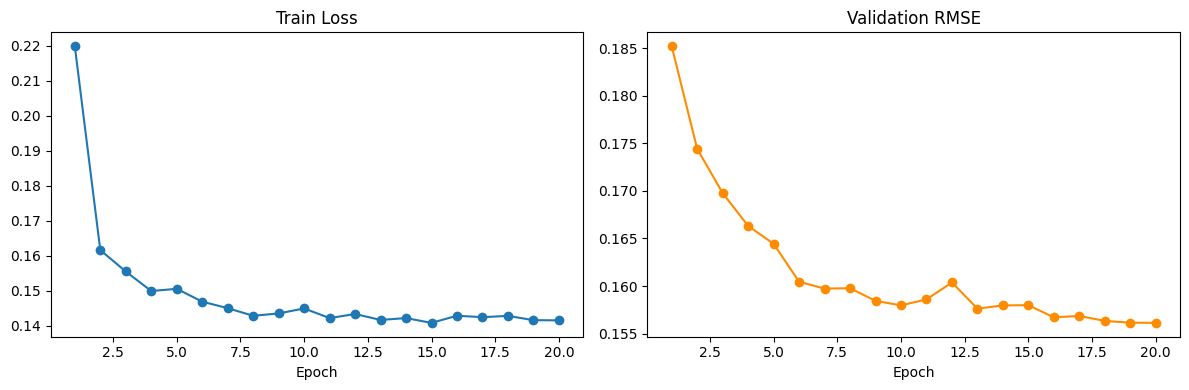

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist_df['epoch'], hist_df['train_loss'], marker='o')
axes[0].set_title('Train Loss')
axes[0].set_xlabel('Epoch')
axes[1].plot(hist_df['epoch'], hist_df['val_rmse'], marker='o', color='darkorange')
axes[1].set_title('Validation RMSE')
axes[1].set_xlabel('Epoch')
plt.tight_layout()

Best val RMSE: 0.15612256824970244


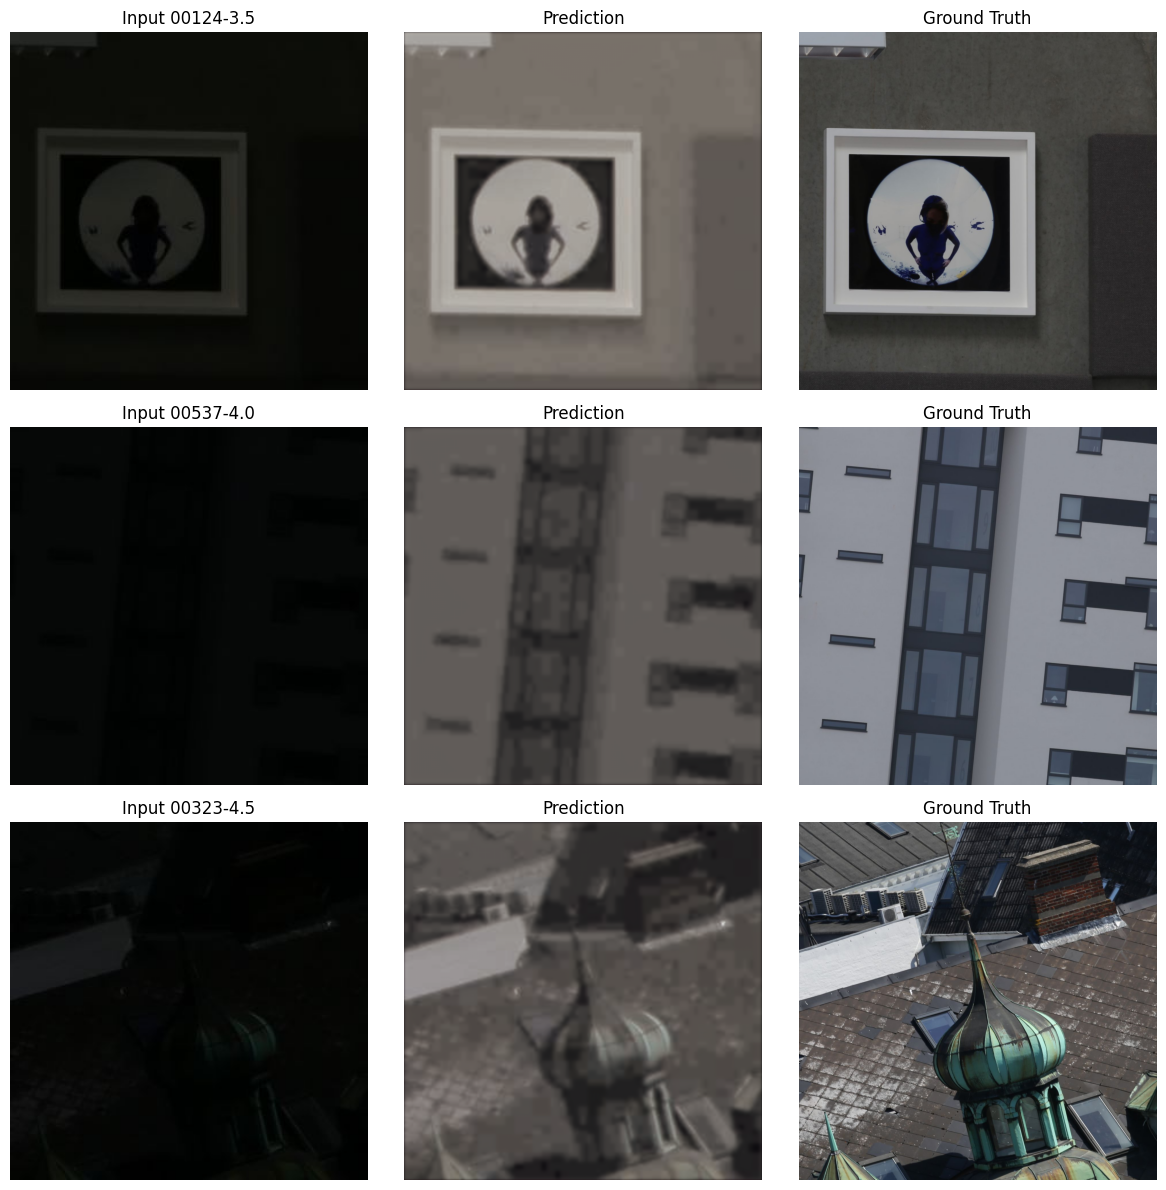

In [11]:
checkpoint = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint['model'])
print('Best val RMSE:', checkpoint['best_rmse'])

sample_batch = random.sample(val_ids, k=min(3, len(val_ids)))
fig, axes = plt.subplots(len(sample_batch), 3, figsize=(12, 4 * len(sample_batch)))
if len(sample_batch) == 1:
    axes = np.array([axes])

for row_idx, image_id in enumerate(sample_batch):
    lr = to_tensor(load_rgb(train_input_map[image_id]))
    gt = load_rgb(train_gt_map[image_id])
    pred = predict_tensor(model, lr).permute(1, 2, 0).numpy()
    pred = np.clip(pred * 255.0, 0, 255).astype(np.uint8)
    axes[row_idx, 0].imshow(load_rgb(train_input_map[image_id]))
    axes[row_idx, 0].set_title(f'Input {image_id}')
    axes[row_idx, 1].imshow(pred)
    axes[row_idx, 1].set_title('Prediction')
    axes[row_idx, 2].imshow(gt)
    axes[row_idx, 2].set_title('Ground Truth')
    for col in range(3):
        axes[row_idx, col].axis('off')
plt.tight_layout()

In [12]:
@torch.no_grad()
def run_test_inference(model, test_files, out_dir):
    model.eval()
    out_dir.mkdir(parents=True, exist_ok=True)
    for path in test_files:
        lr = to_tensor(load_rgb(path)).to(DEVICE)
        pred = model(lr.unsqueeze(0)).squeeze(0).permute(1, 2, 0).cpu().numpy()
        pred = np.clip(pred * 255.0, 0, 255).astype(np.uint8)
        Image.fromarray(pred).save(out_dir / f'{path.stem}.jpg', quality=95)

run_test_inference(model, test_input_files, PRED_DIR)
print('Saved predictions:', len(list(PRED_DIR.glob('*.jpg'))))

Saved predictions: 300


In [13]:
def generate_submission(folder_path, sample_path, output_csv='submission.csv'):
    TARGET_PIXELS = 100
    sample = pd.read_csv(sample_path)
    rows = []

    first_id = sample['ID'].iloc[0]
    first_path = os.path.join(folder_path, first_id + '.jpg')
    if not os.path.exists(first_path):
        raise ValueError(f'Missing file: {first_id}.jpg')

    first_img = np.array(Image.open(first_path).convert('L'))
    flat_size = first_img.size
    indices = np.linspace(0, flat_size - 1, TARGET_PIXELS, dtype=int)

    for image_id in sample['ID']:
        path = os.path.join(folder_path, image_id + '.jpg')
        if not os.path.exists(path):
            raise ValueError(f'Missing file: {image_id}.jpg')

        arr = np.array(Image.open(path).convert('L')).flatten()
        if arr.size != flat_size:
            raise ValueError(f'Image size mismatch for {image_id}.jpg')

        rows.append([image_id, *arr[indices]])

    columns = ['ID'] + [f'pixel_{i}' for i in range(TARGET_PIXELS)]
    df = pd.DataFrame(rows, columns=columns)
    df.to_csv(output_csv, index=False)
    print('Submission saved:', output_csv)
    print('Submission shape:', df.shape)
    return df

sub_df = generate_submission(str(PRED_DIR), str(SAMPLE_SUB), output_csv=str(OUTPUT_DIR / 'submission.csv'))
sub_df.head()

Submission saved: /kaggle/working/nppe3_outputs/submission.csv
Submission shape: (300, 101)


,ID,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,...,pixel_90,pixel_91,pixel_92,pixel_93,pixel_94,pixel_95,pixel_96,pixel_97,pixel_98,pixel_99
0,00003-3.5,57,134,133,131,133,133,131,133,134,...,87,74,71,80,86,90,105,108,115,37
1,00012-4.5,46,73,74,121,77,83,98,44,68,...,81,78,102,31,41,80,116,89,62,31
2,00013-3.0,37,120,119,94,129,93,115,127,95,...,127,113,113,111,88,126,88,108,128,40
3,00017-2.5,77,158,157,157,157,157,157,157,158,...,136,148,64,215,131,125,221,95,170,67
4,00017-4.0,46,115,114,114,114,114,114,114,114,...,90,104,33,150,85,73,151,63,113,39


## Notes

- If training is stable, increase epochs to 30 to 40.
- If GPU memory is tight, reduce `batch_size` to 8.
- If the model underfits, raise `base` channels from 48 to 64.
- If the model over-smooths, increase the edge-loss weight slightly.
- Kaggle output files are written under `/kaggle/working/nppe3_outputs`.